# SIM 1010s — Analysis

Simulations 1010–1019: hexagonal random foam compressed at 10 internal pressure levels

Pressure series: `P = [0.0] + [0.004 × √2^i for i in 0..8]`

**Plots**
1. Reaction force vs displacement — all sims
2. Factor `f` (global efficiency tension / compression) vs displacement — all sims
3. Shear mean vs displacement — all sims
4. η_A (area-based) and η_C (aspect-ratio-based) localization indices vs displacement — all sims

In [1]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(1010, 1020)) 


In [2]:
def load_pkl(path):
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_pressure(sim):
    path = os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json')
    if not os.path.exists(path):
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [3]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: f'{p:.6f} MPa' for sim, p in PRESSURES.items()})


{1010: '0.000000 MPa', 1011: '0.040000 MPa', 1012: '0.056569 MPa', 1013: '0.080000 MPa', 1014: '0.113137 MPa', 1015: '0.160000 MPa', 1016: '0.226274 MPa', 1017: '0.320000 MPa', 1018: '0.452548 MPa', 1019: '0.640000 MPa'}


In [4]:
from matplotlib.lines import Line2D

def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim]
        yB = np.interp(xB, displ, y)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=color,
                   edgecolor='k', linewidths=0.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if LOC_A:
        handles.append(Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8))
        labels.append('Localization A')
    if LOC_B:
        handles.append(Line2D([], [], marker='^', linestyle='None', markerfacecolor='0.6', markeredgecolor='k', markersize=8))
        labels.append('Localization B')
    return handles, labels


In [5]:
# LocalizationA = displacement at the minimum of shear_mean, per sim.
# LocalizationB is on standby (not used yet) for SIM 1010s.
LOC_A = {}
LOC_B = {}

for sim in SIMS:
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    idx_min = np.argmin(shear_mean)
    LOC_A[sim] = displ[idx_min]

LOC_A


{1010: 2.450000047683716,
 1011: 2.7649455070495605,
 1012: 2.869150161743164,
 1013: 3.0453219413757324,
 1014: 3.2962982654571533,
 1015: 3.6289710998535156,
 1016: 4.058625221252441,
 1017: 4.619215965270996,
 1018: 5.0}

## Plot 1 — Reaction force vs displacement

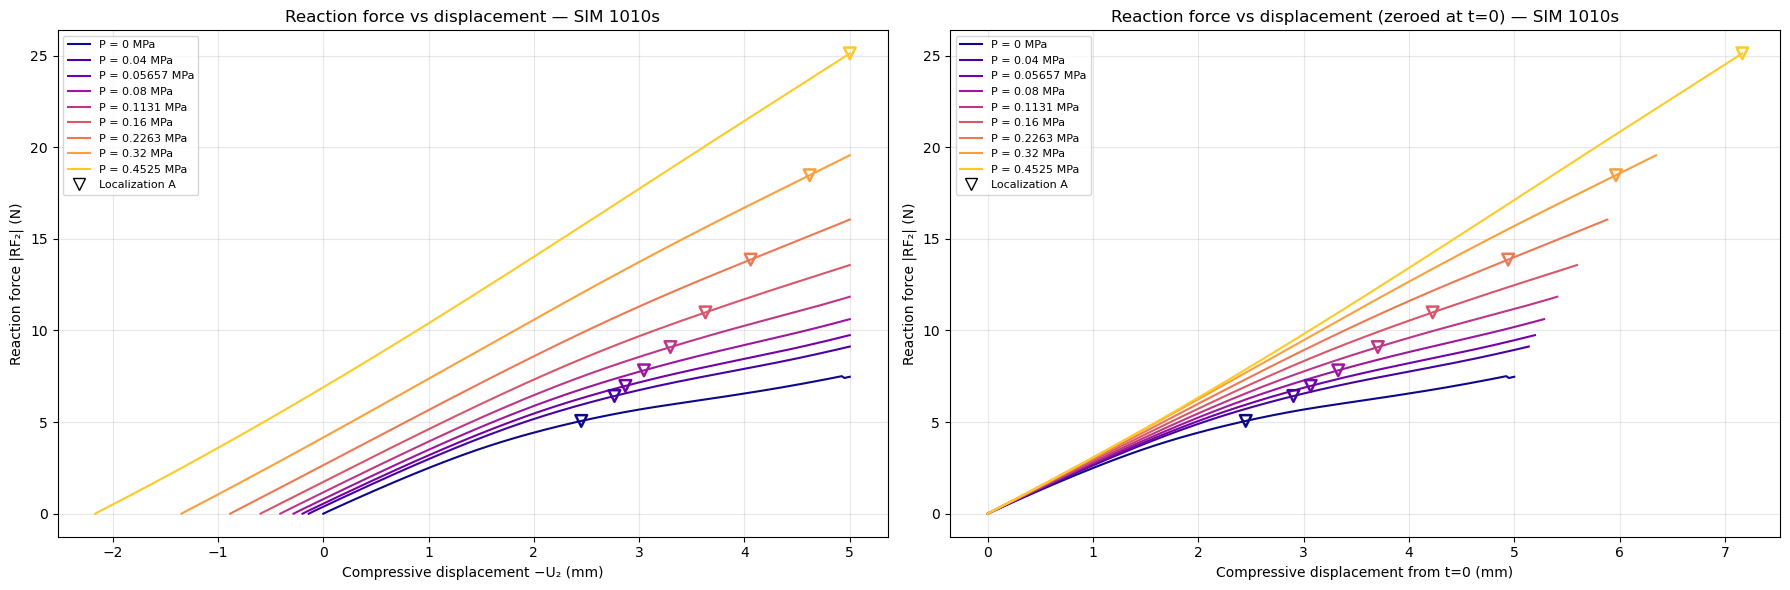

In [6]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    # U2 at PERN-9999997 is signed (positive = pressure-induced expansion in
    # Step-0, ramping down through 0 to the imposed compression in Step-1) and
    # is monotonically decreasing over time. Negate (don't abs!) to get a
    # monotonically increasing compressive-displacement axis.
    displ = -np.array(a2['U2']['PERN-9999997'])
    rf2   = np.abs(np.array(a2['RF2']['PERN-9999997']))
    del a2

    ax.plot(displ, rf2, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, rf2)

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset.
    displ0     = displ[0]
    displ_zero = displ - displ0

    ax2.plot(displ_zero, rf2, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, rf2)
        ax2.scatter(xA, yA, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim] - displ0
        yB = np.interp(xB, displ_zero, rf2)
        ax2.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                    edgecolor='k', linewidths=0.8, zorder=5)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Reaction force |RF₂| (N)')
ax.set_title('Reaction force vs displacement — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

ax2.set_xlabel('Compressive displacement from t=0 (mm)')
ax2.set_ylabel('Reaction force |RF₂| (N)')
ax2.set_title('Reaction force vs displacement (zeroed at t=0) — SIM 1010s')
ax2.legend(*add_localization_legend(ax2), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Plot 1s — Reaction force vs strain (from t=0)

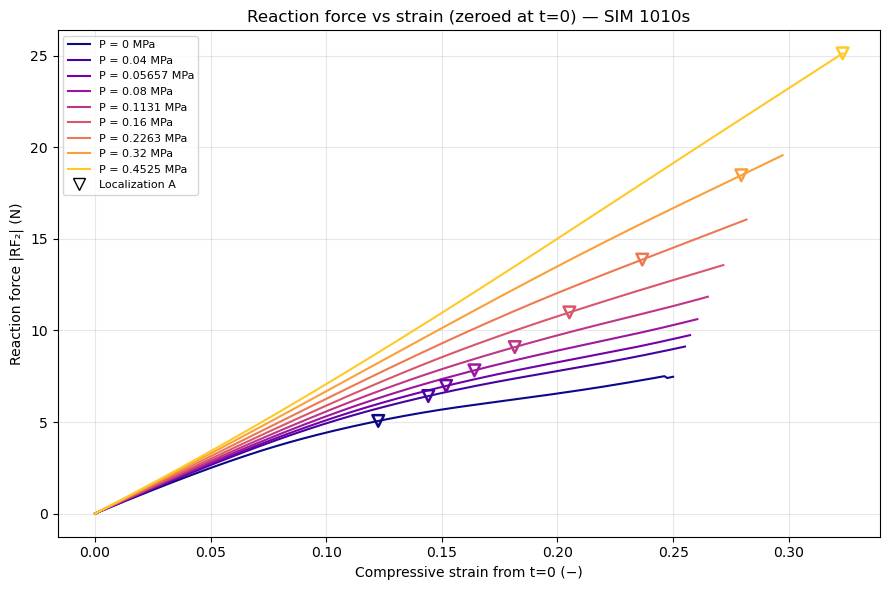

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    rf2   = np.abs(np.array(a2['RF2']['PERN-9999997']))
    del a2

    # Compressive displacement from t=0, and the corresponding strain.
    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    displ0  = displ[0]
    displ_zero = displ - displ0
    height0 = 20 - displ0
    strain  = displ_zero / height0

    ax.plot(strain, rf2, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain, rf2)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = (LOC_B[sim] - displ0) / height0
        yB = np.interp(xB, strain, rf2)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                   edgecolor='k', linewidths=0.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('Reaction force |RF₂| (N)')
ax.set_title('Reaction force vs strain (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Factor `f` (tension / compression efficiency) vs displacement

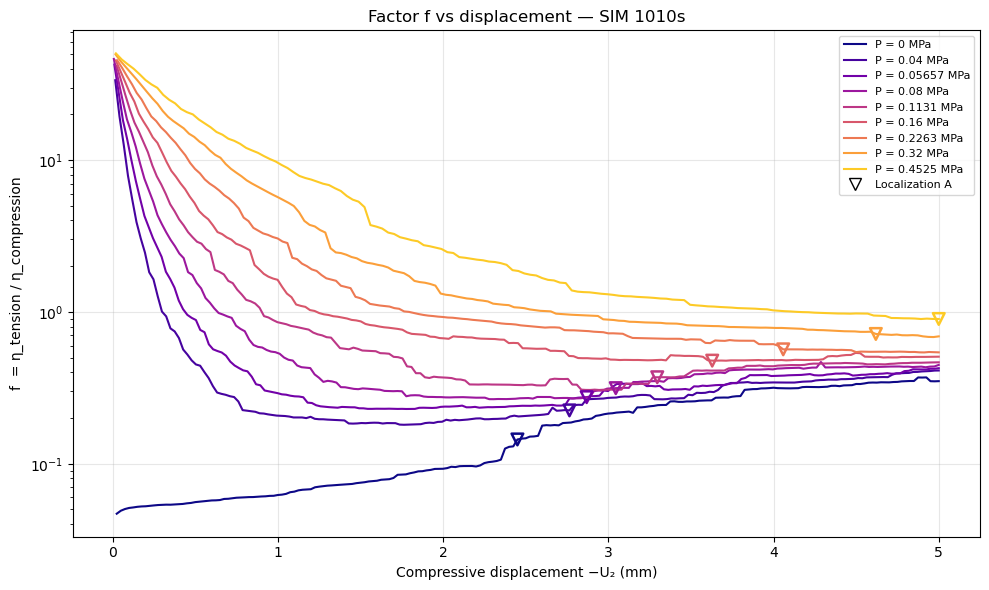

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f) & (displ > 0)
    ax.plot(displ[mask], f[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ[mask], f[mask])

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f vs displacement — SIM 1010s')
ax.set_yscale('log')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2s — Factor `f` (tension / compression efficiency) vs strain (from t=0)

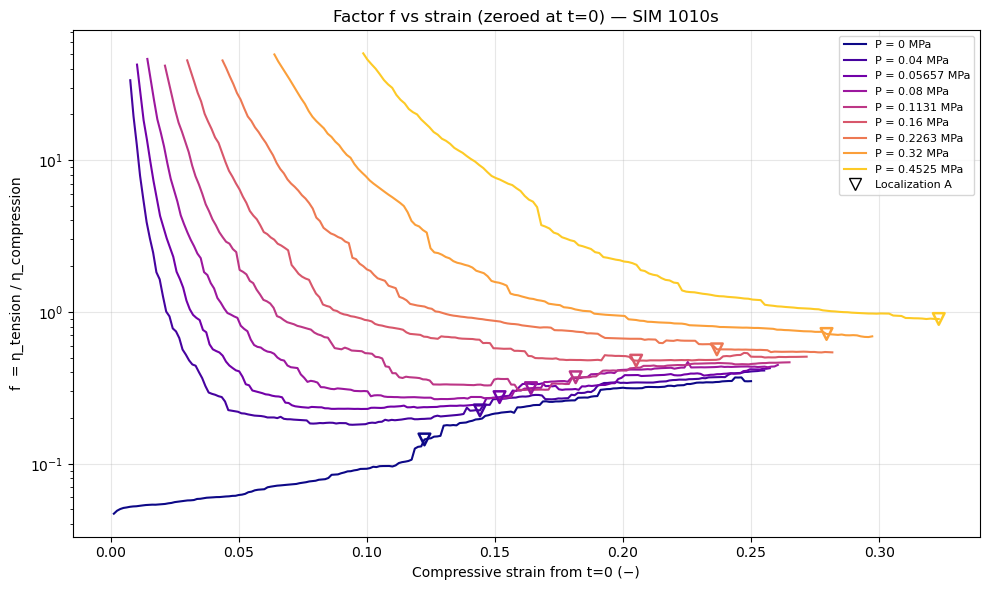

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    # Compressive displacement from t=0, and the corresponding strain.
    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    displ0  = displ[0]
    displ_zero = displ - displ0
    height0 = 20 - displ0
    strain  = displ_zero / height0

    mask = ~np.isnan(f) & (displ > 0)
    ax.plot(strain[mask], f[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain[mask], f[mask])
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = (LOC_B[sim] - displ0) / height0
        yB = np.interp(xB, strain[mask], f[mask])
        ax.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                   edgecolor='k', linewidths=0.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f vs strain (zeroed at t=0) — SIM 1010s')
ax.set_yscale('log')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — Shear mean vs displacement

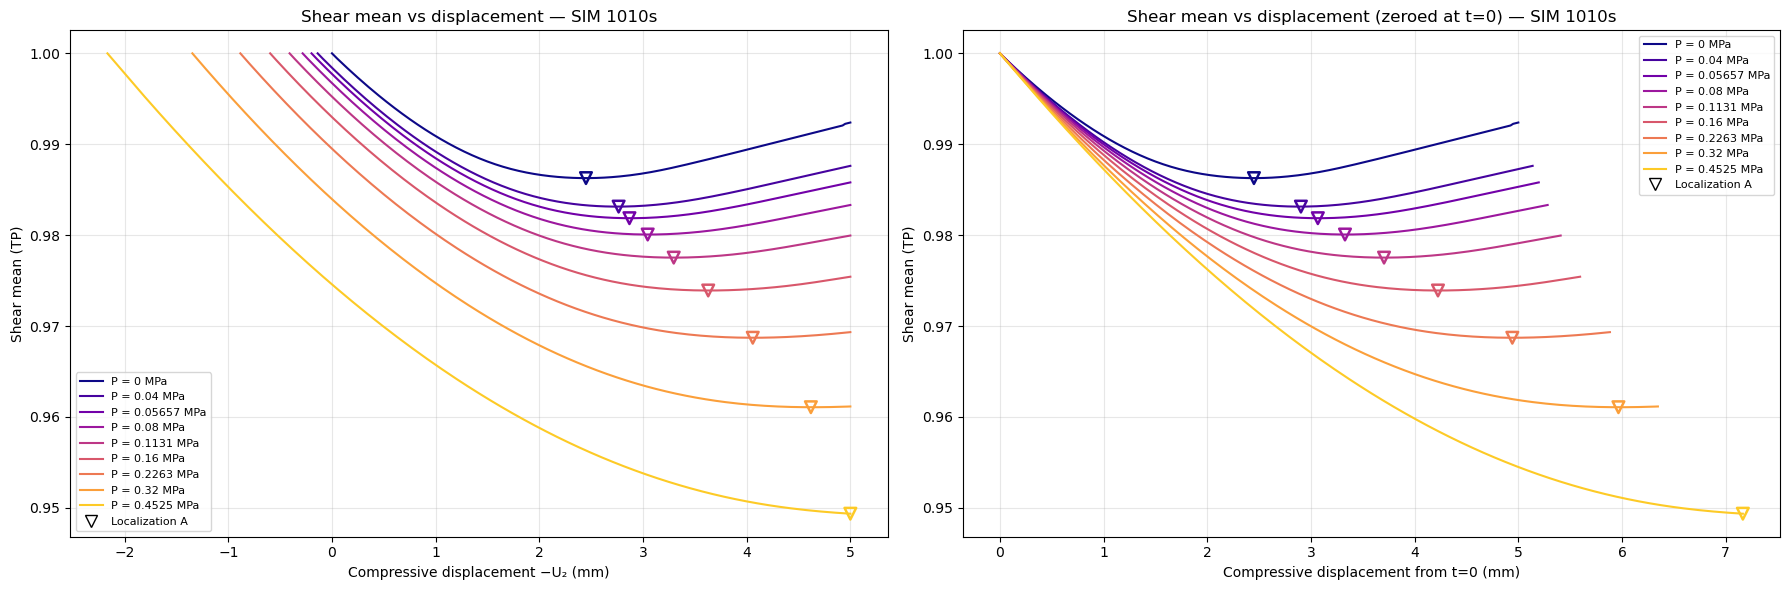

In [10]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(18, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    ax.plot(displ, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, shear_mean)

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset.
    displ0     = displ[0]
    displ_zero = displ - displ0

    ax2.plot(displ_zero, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_mean)
        ax2.scatter(xA, yA, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim] - displ0
        yB = np.interp(xB, displ_zero, shear_mean)
        ax2.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                    edgecolor='k', linewidths=0.8, zorder=5)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

ax2.set_xlabel('Compressive displacement from t=0 (mm)')
ax2.set_ylabel('Shear mean (TP)')
ax2.set_title('Shear mean vs displacement (zeroed at t=0) — SIM 1010s')
ax2.legend(*add_localization_legend(ax2), loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Plot 3s — Shear mean vs strain (from t=0)

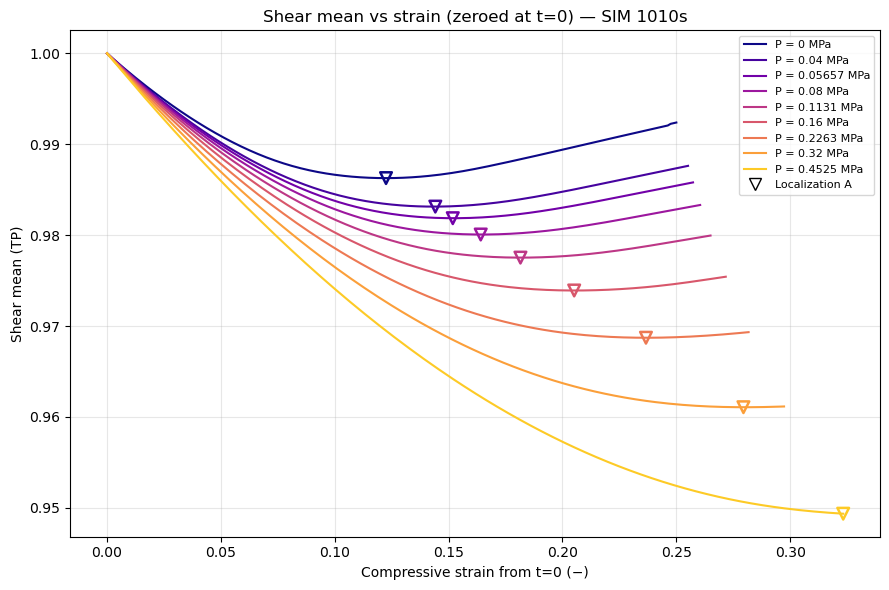

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    # Compressive displacement from t=0, and the corresponding strain.
    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    displ0  = displ[0]
    displ_zero = displ - displ0
    height0 = 20 - displ0
    strain  = displ_zero / height0

    ax.plot(strain, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain, shear_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = (LOC_B[sim] - displ0) / height0
        yB = np.interp(xB, strain, shear_mean)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                   edgecolor='k', linewidths=0.8, zorder=5)

ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs strain (zeroed at t=0) — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3b — d(Shear mean)/d(displacement) vs displacement

In [12]:
import plotly.graph_objects as go

fig = go.Figure()
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    dshear_dd = np.gradient(shear_mean, displ)
    r, g, b, _ = cmap(idx)
    color = f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'

    fig.add_trace(go.Scatter(
        x=displ, y=dshear_dd, mode='lines+markers',
        marker=dict(size=4), line=dict(color=color),
        name=f'SIM {sim} — P = {PRESSURES[sim]:.4g} MPa',
        hovertemplate='SIM %{text}<br>displ = %{x:.4f} mm<br>d(shear)/d(displ) = %{y:.5f}<extra></extra>',
        text=[str(sim)] * len(displ),
    ))

fig.update_layout(
    title='Shear mean derivative vs displacement — SIM 1010s (zoom/pan/hover to pick Localization A/B)',
    xaxis_title='Compressive displacement −U₂ (mm)',
    yaxis_title='d(Shear mean)/d(displacement) (TP/mm)',
    width=1010, height=650,
    hovermode='closest',
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()


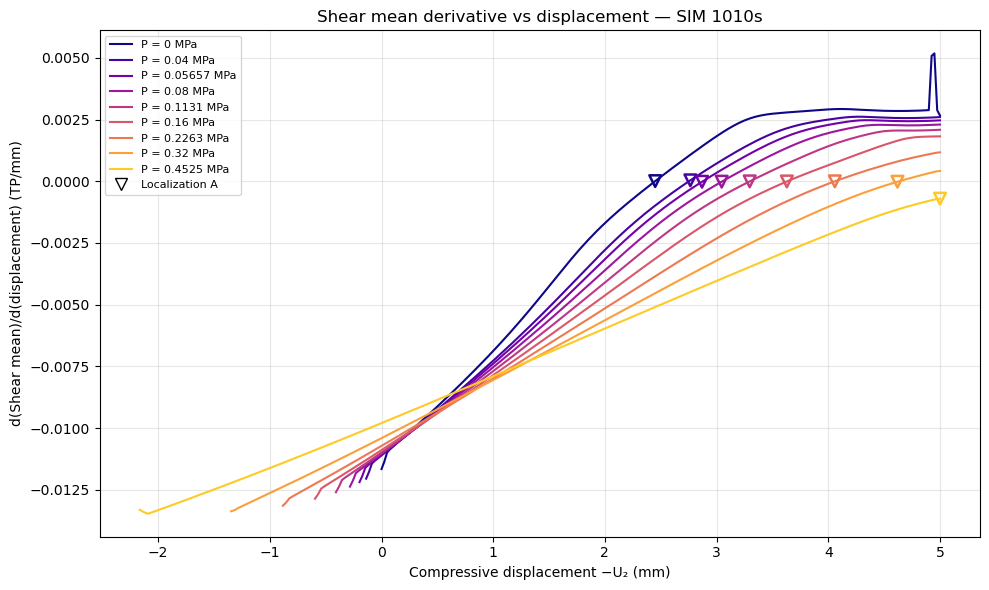

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    dshear_dd = np.gradient(shear_mean, displ)

    ax.plot(displ, dshear_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, dshear_dd)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — $\eta_A$ (area-based) and $\eta_C$ (aspect-ratio-based) localization indices vs displacement

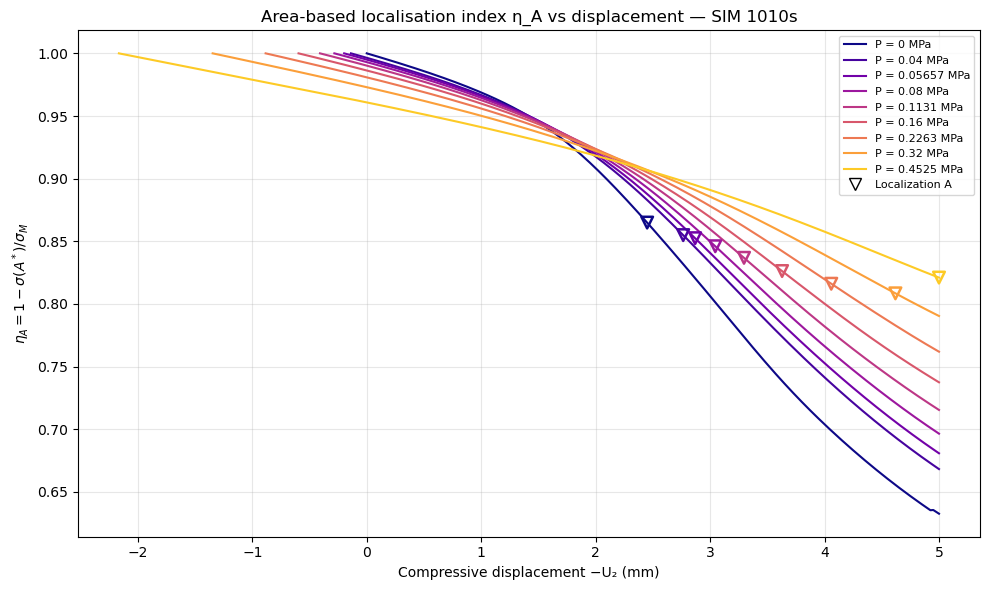

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    # displacement here matches A2's U2 sign convention (signed, decreasing).
    displ  = -np.array(defc2['displacement'])
    eta_a  = np.array(defc2['etaC_A'])
    del defc2

    ax.plot(displ, eta_a, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, eta_a)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_A = 1 - \sigma(A^*)/\sigma_M$')
ax.set_title('Area-based localisation index η_A vs displacement — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


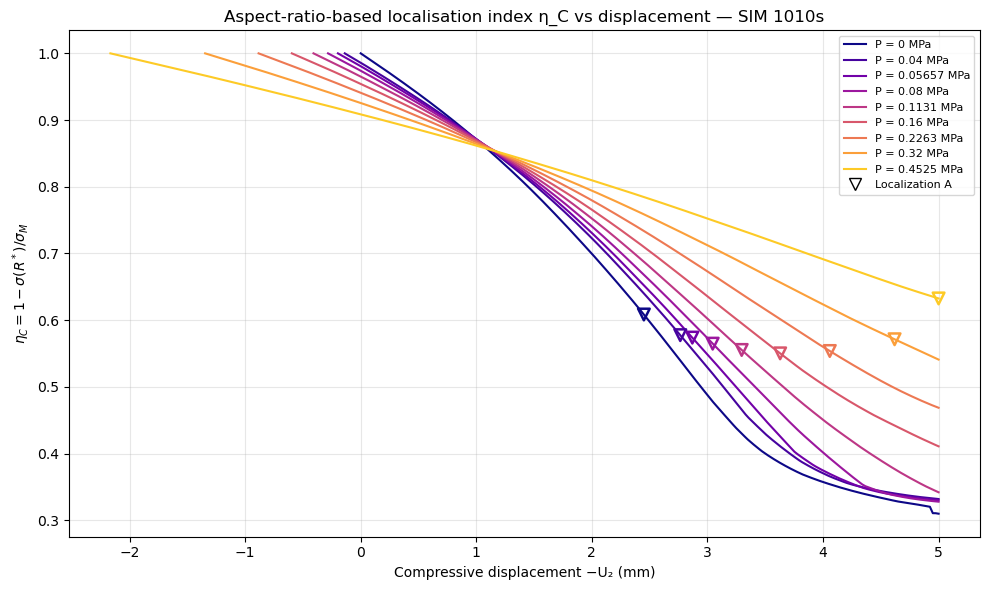

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    displ  = -np.array(defc2['displacement'])
    eta_c  = np.array(defc2['etaC_R'])
    del defc2

    ax.plot(displ, eta_c, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    mark_localizations(ax, cmap(idx), sim, displ, eta_c)

ax.set_xlabel('Compressive displacement −U₂ (mm)')
ax.set_ylabel(r'$\eta_C = 1 - \sigma(R^*)/\sigma_M$')
ax.set_title('Aspect-ratio-based localisation index η_C vs displacement — SIM 1010s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 5 — Localization-point summary (factor f, displacement) vs internal pressure

In [16]:
loc_data = []
for sim in SIMS:
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None or sim not in PRESSURES:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f) & (displ > 0)
    displ_m, f_m = displ[mask], f[mask]

    # displ[0] is the displacement at t=0 (start of the simulation, before the
    # Step-0 pressure ramp), which is nonzero/negative in this signed
    # convention. Subtracting it gives the absolute compressive displacement
    # measured from the true start of the simulation.
    displ0 = displ[0]

    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    height0 = 20 - displ0

    dispA = LOC_A.get(sim, np.nan)
    dispB = LOC_B.get(sim, np.nan)
    fA = np.interp(dispA, displ_m, f_m) if sim in LOC_A else np.nan
    fB = np.interp(dispB, displ_m, f_m) if sim in LOC_B else np.nan

    dispA_abs = dispA - displ0
    dispB_abs = dispB - displ0

    loc_data.append(dict(sim=sim, P=PRESSURES[sim], displ0=displ0, height0=height0,
                          dispA=dispA, dispA_abs=dispA_abs, strainA=dispA_abs / height0, fA=fA,
                          dispB=dispB, dispB_abs=dispB_abs, strainB=dispB_abs / height0, fB=fB))

loc_data.sort(key=lambda d: d['P'])
loc_data


[{'sim': 1010,
  'P': 0.0,
  'displ0': -0.0,
  'height0': 20.0,
  'dispA': 2.450000047683716,
  'dispA_abs': 2.450000047683716,
  'strainA': 0.12250000238418579,
  'fA': 0.14444076255846977,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'sim': 1011,
  'P': 0.04,
  'displ0': -0.13805629312992096,
  'height0': 20.13805629312992,
  'dispA': 2.7649455070495605,
  'dispA_abs': 2.9030018001794815,
  'strainA': 0.14415501466096498,
  'fA': 0.22445182569199754,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'sim': 1012,
  'P': 0.05656854249492381,
  'displ0': -0.1971948742866516,
  'height0': 20.19719487428665,
  'dispA': 2.869150161743164,
  'dispA_abs': 3.0663450360298157,
  'strainA': 0.1518203421373938,
  'fA': 0.27436776178923233,
  'dispB': nan,
  'dispB_abs': nan,
  'strainB': nan,
  'fB': nan},
 {'sim': 1013,
  'P': 0.08000000000000002,
  'displ0': -0.2829137146472931,
  'height0': 20.282913714647293,
  'dispA': 3.0453219413757324,
  'disp

### Plot 5a — Factor f at localization points vs internal pressure

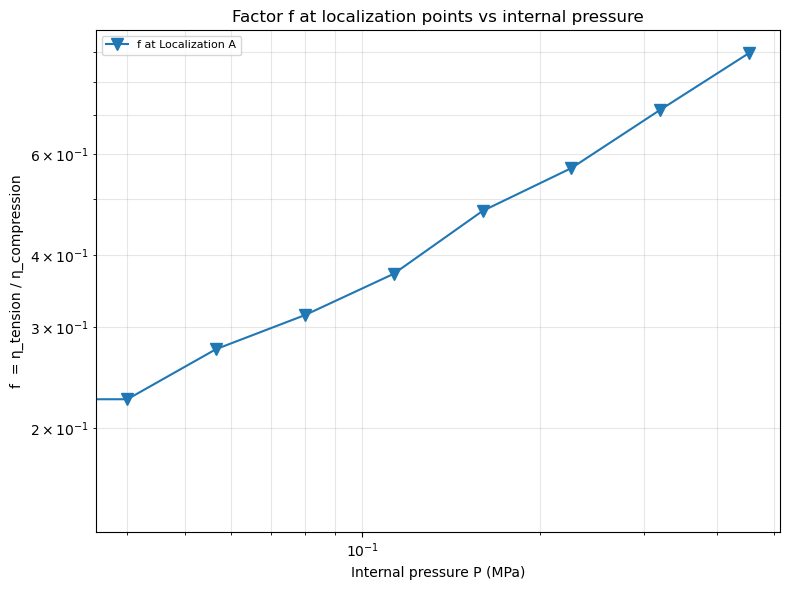

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

dA = [row for row in loc_data if np.isfinite(row['P']) and np.isfinite(row['fA'])]
dB = [row for row in loc_data if np.isfinite(row['P']) and np.isfinite(row['fB'])]

ax.plot([row['P'] for row in dA], [row['fA'] for row in dA], marker='v', ms=8,
        color='tab:blue', label='f at Localization A')
if dB:
    ax.plot([row['P'] for row in dB], [row['fB'] for row in dB], marker='^', ms=8,
            color='tab:red', label='f at Localization B')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Internal pressure P (MPa)')
ax.set_ylabel('f  = η_tension / η_compression')
ax.set_title('Factor f at localization points vs internal pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


### Plot 5b — Displacement at localization points vs internal pressure (raw and absolute)

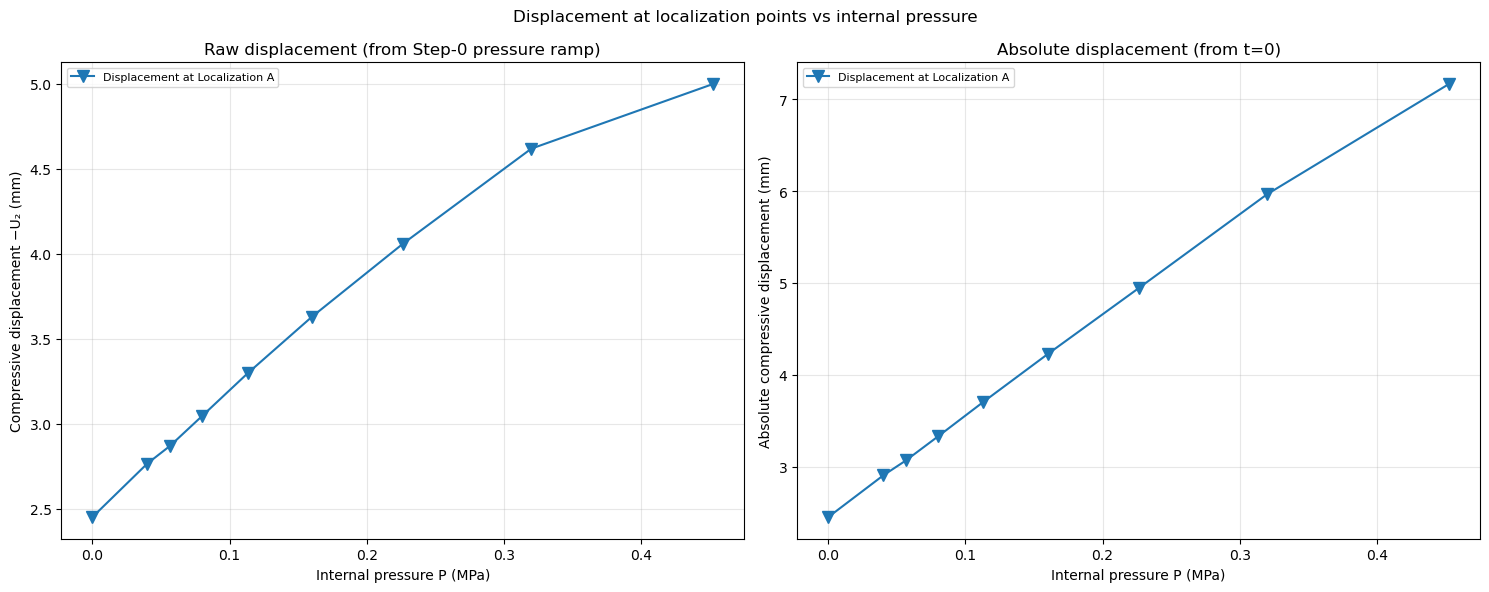

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

dA = [d for d in loc_data if not np.isnan(d['dispA'])]
dB = [d for d in loc_data if not np.isnan(d['dispB'])]

ax1.plot([d['P'] for d in dA], [d['dispA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Displacement at Localization A')
if dB:
    ax1.plot([d['P'] for d in dB], [d['dispB'] for d in dB], marker='^', ms=8,
             color='tab:red', label='Displacement at Localization B')

ax1.set_xlabel('Internal pressure P (MPa)')
ax1.set_ylabel('Compressive displacement −U₂ (mm)')
ax1.set_title('Raw displacement (from Step-0 pressure ramp)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Absolute displacement: raw displacement minus displ(t=0), so every sim's
# displacement axis starts at 0 regardless of the pressure-induced expansion
# each one starts from.
ax2.plot([d['P'] for d in dA], [d['dispA_abs'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Displacement at Localization A')
if dB:
    ax2.plot([d['P'] for d in dB], [d['dispB_abs'] for d in dB], marker='^', ms=8,
             color='tab:red', label='Displacement at Localization B')

ax2.set_xlabel('Internal pressure P (MPa)')
ax2.set_ylabel('Absolute compressive displacement (mm)')
ax2.set_title('Absolute displacement (from t=0)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('Displacement at localization points vs internal pressure')
fig.tight_layout()
plt.show()


### Plot 5bs — Strain at localization points vs internal pressure

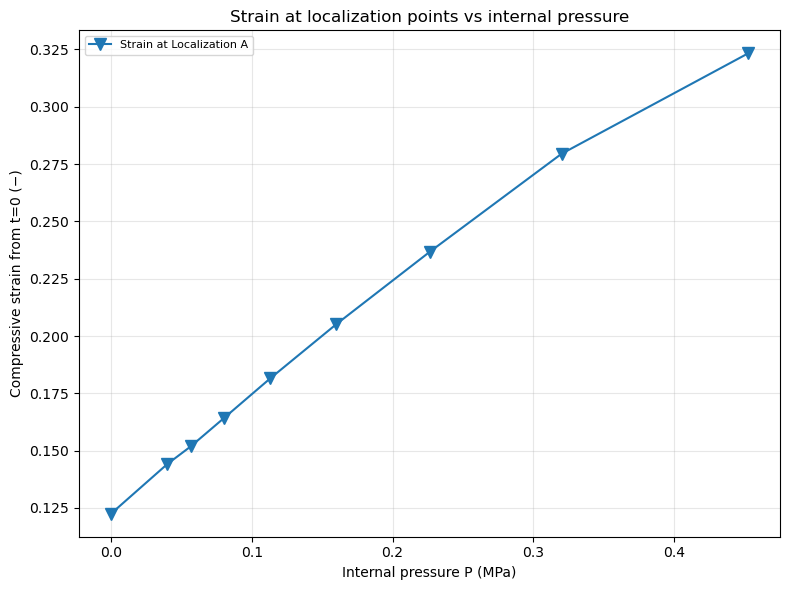

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

dA = [d for d in loc_data if not np.isnan(d['strainA'])]
dB = [d for d in loc_data if not np.isnan(d['strainB'])]

ax.plot([d['P'] for d in dA], [d['strainA'] for d in dA], marker='v', ms=8,
        color='tab:blue', label='Strain at Localization A')
if dB:
    ax.plot([d['P'] for d in dB], [d['strainB'] for d in dB], marker='^', ms=8,
            color='tab:red', label='Strain at Localization B')

ax.set_xlabel('Internal pressure P (MPa)')
ax.set_ylabel('Compressive strain from t=0 (−)')
ax.set_title('Strain at localization points vs internal pressure')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


### Plot 5c — Factor f at localization point vs displacement at localization point (raw and absolute)

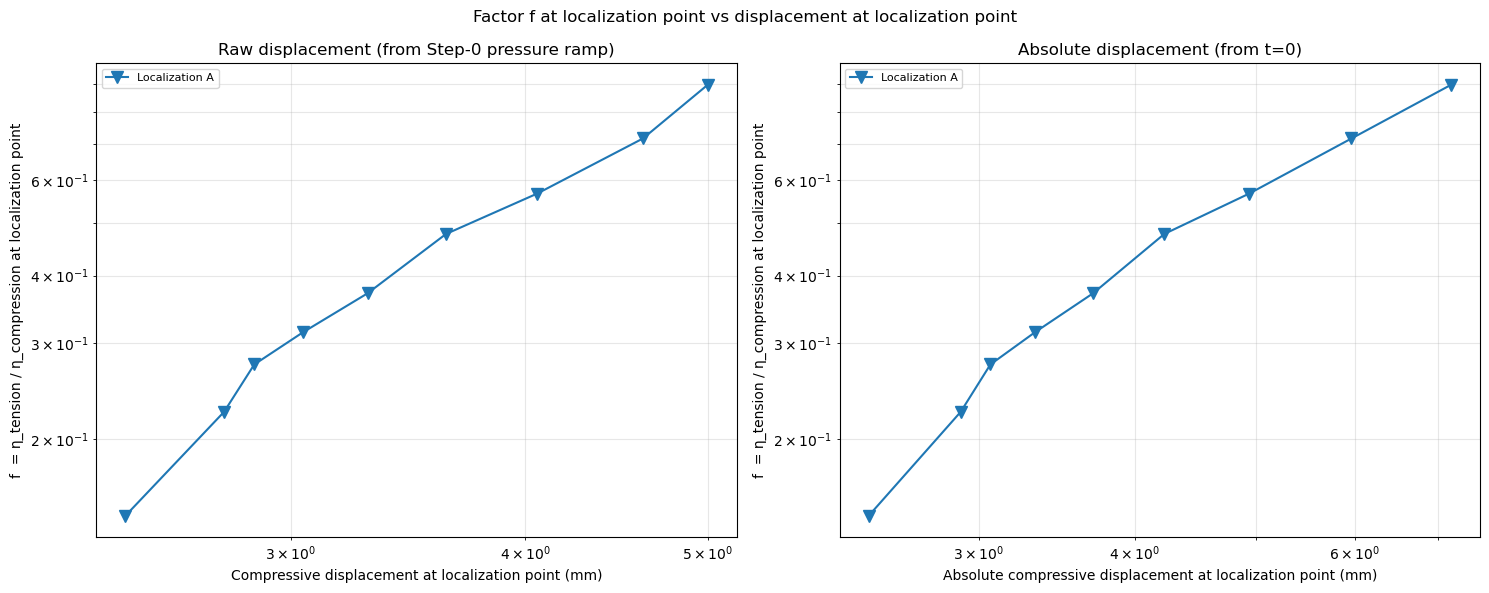

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

dA = [d for d in loc_data if not np.isnan(d['fA'])]
dB = [d for d in loc_data if not np.isnan(d['fB'])]

ax1.plot([d['dispA'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Localization A')
if dB:
    ax1.plot([d['dispB'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
             color='tab:red', label='Localization B')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Compressive displacement at localization point (mm)')
ax1.set_ylabel('f  = η_tension / η_compression at localization point')
ax1.set_title('Raw displacement (from Step-0 pressure ramp)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, which='both')

# Absolute displacement: raw displacement minus displ(t=0), so every sim's
# displacement axis starts at 0 regardless of the pressure-induced expansion
# each one starts from.
ax2.plot([d['dispA_abs'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
         color='tab:blue', label='Localization A')
if dB:
    ax2.plot([d['dispB_abs'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
             color='tab:red', label='Localization B')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Absolute compressive displacement at localization point (mm)')
ax2.set_ylabel('f  = η_tension / η_compression at localization point')
ax2.set_title('Absolute displacement (from t=0)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, which='both')

fig.suptitle('Factor f at localization point vs displacement at localization point')
fig.tight_layout()
plt.show()


### Plot 5cs — Factor f at localization point vs strain at localization point (from t=0)

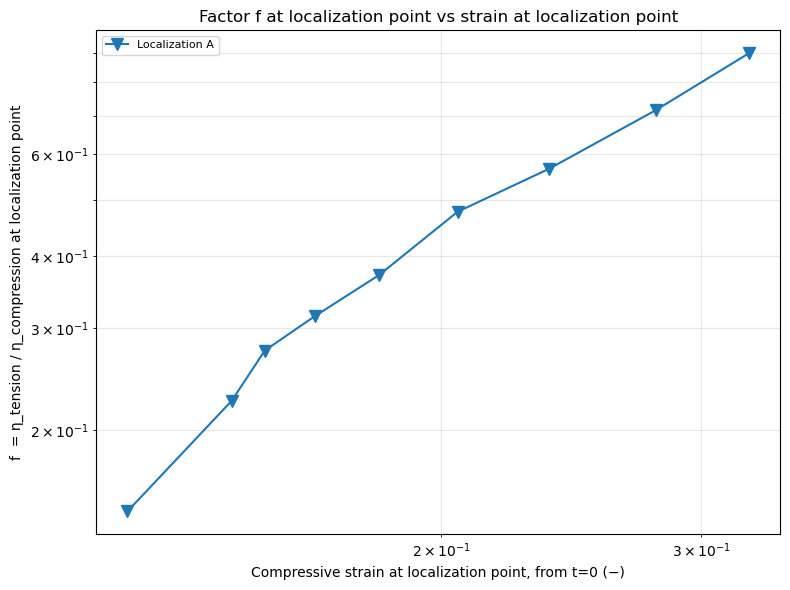

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

dA = [d for d in loc_data if not np.isnan(d['fA'])]
dB = [d for d in loc_data if not np.isnan(d['fB'])]

ax.plot([d['strainA'] for d in dA], [d['fA'] for d in dA], marker='v', ms=8,
        color='tab:blue', label='Localization A')
if dB:
    ax.plot([d['strainB'] for d in dB], [d['fB'] for d in dB], marker='^', ms=8,
            color='tab:red', label='Localization B')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Compressive strain at localization point, from t=0 (−)')
ax.set_ylabel('f  = η_tension / η_compression at localization point')
ax.set_title('Factor f at localization point vs strain at localization point')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


## Plot 6 — 3 smallest stiffness-matrix eigenvalues vs time

Reads `DATA_PICK_{sim}_E.pkl` (written by `A001_functions.stiffness_eigen.create_PKL_E`),
which holds the smallest eigenvalues of the tangent stiffness matrix at each output frame
of Step-1 (see `A001_functions/stiffness_eigen.py`). Each sim gets one color (by pressure)
and the 3 smallest eigenvalues are drawn as solid / dashed / dotted lines of that color.
Falls back to a single line if an `_E.pkl` predates the multi-eigenvalue change (only has
the scalar `lambda_min`). Missing entirely for sims where the eigen extraction hasn't been
(successfully) run yet.

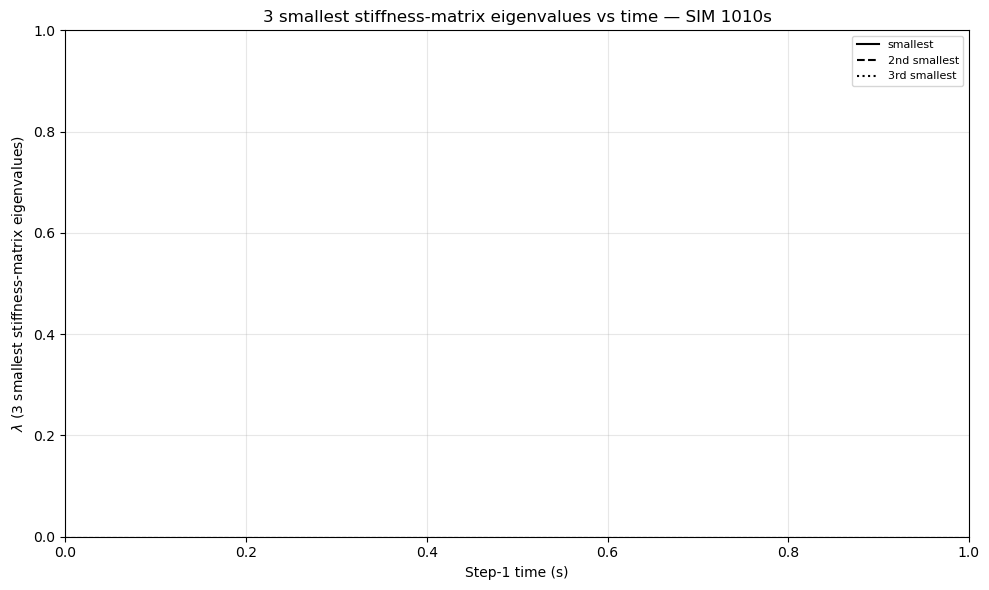

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))
RANK_STYLES = ['-', '--', ':']
N_RANKS = 3
RANK_NAMES = ['smallest', '2nd smallest', '3rd smallest']

for idx, sim in enumerate(SIMS):
    e_data = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim:03d}_E.pkl'))
    if e_data is None:
        continue
    t = np.array(e_data['t'])
    if t.size == 0:
        continue
    # 'eigenvalues' holds the n_eigenvalues smallest eigenvalues (ascending)
    # per frame; older E.pkl files only have the single smallest ('lambda_min').
    if 'eigenvalues' in e_data:
        eigvals = np.array(e_data['eigenvalues'])
    else:
        eigvals = np.array(e_data['lambda_min'])[:, None]
    del e_data

    n_ranks = min(N_RANKS, eigvals.shape[1])
    for rank in range(n_ranks):
        ax.plot(t, eigvals[:, rank], color=cmap(idx), linestyle=RANK_STYLES[rank],
                marker='o', ms=3,
                label=f'P = {PRESSURES[sim]:.4g} MPa' if rank == 0 else None)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('Step-1 time (s)')
ax.set_ylabel(r'$\lambda$ (3 smallest stiffness-matrix eigenvalues)')
ax.set_title('3 smallest stiffness-matrix eigenvalues vs time — SIM 1010s')

handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([], [], color='k', linestyle=RANK_STYLES[r]) for r in range(N_RANKS)]
labels += RANK_NAMES
ax.legend(handles, labels, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 6b — 3 smallest stiffness-matrix eigenvalues vs displacement (from t=0)

Same as Plot 6 but with displacement instead of time on the x-axis, and Localization
A/B markers on the smallest-eigenvalue line (the same LOC_A/LOC_B convention as the
other plots). Eigenvalue extraction points are indexed by Step-1 step time, which uses
the same 0–1 time base as `DATA_PICK_{sim}_A2.pkl`'s `t` (both start at the end of the
Step-0 pressure ramp). So each eigenvalue's displacement is obtained by interpolating
A2's `t → -U2` onto the eigenvalue `t` grid, then zeroing at t=0 exactly like Plot
1/Plot 3's zeroed panels.

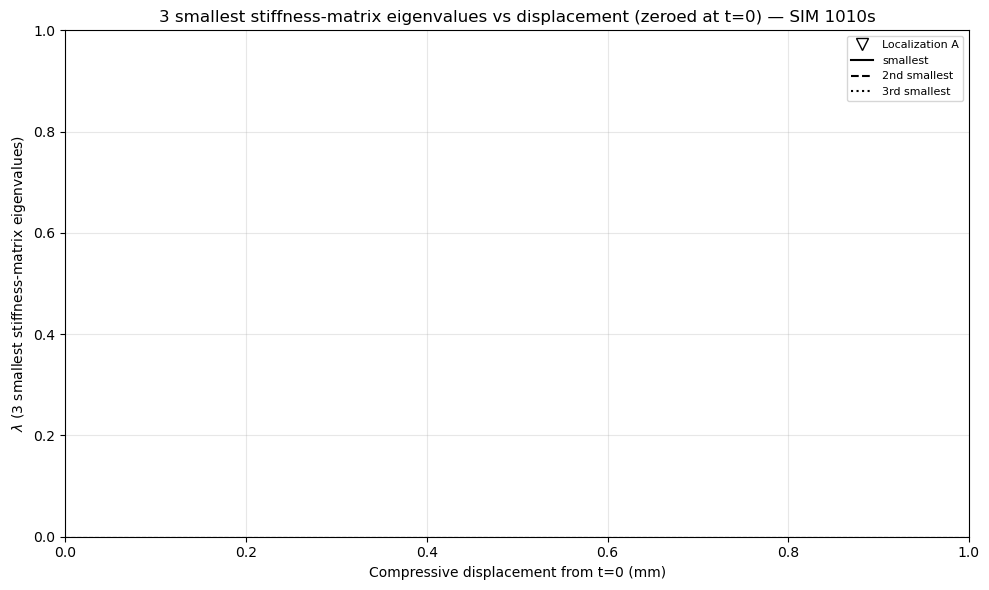

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))
RANK_STYLES = ['-', '--', ':']
N_RANKS = 3
RANK_NAMES = ['smallest', '2nd smallest', '3rd smallest']

for idx, sim in enumerate(SIMS):
    a2     = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    e_data = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim:03d}_E.pkl'))
    if a2 is None or e_data is None:
        del a2, e_data
        continue
    a2_t  = np.array(a2['t'])
    displ = -np.array(a2['U2']['PERN-9999997'])
    eig_t = np.array(e_data['t'])
    # 'eigenvalues' holds the n_eigenvalues smallest eigenvalues (ascending)
    # per frame; older E.pkl files only have the single smallest ('lambda_min').
    if 'eigenvalues' in e_data:
        eigvals = np.array(e_data['eigenvalues'])
    else:
        eigvals = np.array(e_data['lambda_min'])[:, None]
    del a2, e_data

    # Skip sims whose eigenvalue extraction hasn't produced any points yet
    # (e.g. a stale/empty DATA_PICK_{sim}_E.pkl) - nothing to plot or
    # interpolate localization markers against.
    if eig_t.size == 0:
        continue

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset (same convention
    # as Plot 1/Plot 3's zeroed panels).
    displ0     = displ[0]
    displ_zero = displ - displ0

    # Eigenvalue extraction points are indexed by Step-1 step time, not by
    # displacement - interpolate onto A2's time grid to get the displacement
    # at each extraction point.
    eig_displ_zero = np.interp(eig_t, a2_t, displ_zero)

    n_ranks = min(N_RANKS, eigvals.shape[1])
    for rank in range(n_ranks):
        ax.plot(eig_displ_zero, eigvals[:, rank], color=cmap(idx), linestyle=RANK_STYLES[rank],
                marker='o', ms=3,
                label=f'P = {PRESSURES[sim]:.4g} MPa' if rank == 0 else None)

    # Localization markers only on the smallest-eigenvalue line, to keep the
    # plot readable.
    lambda_min = eigvals[:, 0]
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, eig_displ_zero, lambda_min)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)
    if sim in LOC_B:
        xB = LOC_B[sim] - displ0
        yB = np.interp(xB, eig_displ_zero, lambda_min)
        ax.scatter(xB, yB, marker='^', s=70, facecolor=cmap(idx),
                   edgecolor='k', linewidths=0.8, zorder=5)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'$\lambda$ (3 smallest stiffness-matrix eigenvalues)')
ax.set_title('3 smallest stiffness-matrix eigenvalues vs displacement (zeroed at t=0) — SIM 1010s')

handles, labels = add_localization_legend(ax)
handles += [Line2D([], [], color='k', linestyle=RANK_STYLES[r]) for r in range(N_RANKS)]
labels += RANK_NAMES
ax.legend(handles, labels, loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
